In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('Global_Superstore2.csv', encoding='latin1')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [3]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [4]:
pd.set_option('display.max_columns', None)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,NaN,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [5]:
df = df.drop(columns=['Product ID', 'Customer ID', 'Order ID', 'Postal Code'])

In [6]:
df['Sales'] = df['Sales'].round(2)
df['Profit'] = df['Profit'].round(2)
df['Shipping Cost'] = df['Shipping Cost'].round(2)
df['Discount'] = (df['Discount'] * 100).astype(int)


In [7]:
text_columns = df.select_dtypes(
    include='object'
).columns

for col in text_columns:
    df[col] = df[col].str.strip()

C:\Users\rishi\AppData\Local\Temp\ipykernel_26092\445489702.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(


In [8]:
df.head()

,Row ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,31-07-2012,31-07-2012,Same Day,Rick Hansen,Consumer,New York City,New York,United States,US,East,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.65,7,0,762.18,933.57,Critical
1,26341,05-02-2013,07-02-2013,Second Class,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,10,-288.76,923.63,Critical
2,25330,17-10-2013,18-10-2013,First Class,Craig Reiter,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,10,919.97,915.49,Medium
3,13524,28-01-2013,30-01-2013,First Class,Katherine Murray,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,10,-96.54,910.16,Medium
4,47221,05-11-2013,06-11-2013,Same Day,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0,311.52,903.04,Critical


In [9]:
pd.set_option('display.max_rows', None)

df['Ship Mode'].value_counts()

Ship Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64

In [10]:
df['Segment'].value_counts()

Segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64

In [11]:
df['City'].value_counts()

City
New York City                          915
Los Angeles                            747
Philadelphia                           537
San Francisco                          510
Santo Domingo                          443
Manila                                 432
Seattle                                428
Houston                                377
Tegucigalpa                            362
Jakarta                                337
Managua                                336
Lagos                                  333
Chicago                                314
Istanbul                               314
Mexico City                            300
Bangkok                                287
London                                 281
Sydney                                 271
Cairo                                  248
Vienna                                 245
Melbourne                              235
Columbus                               222
San Salvador                           221
Berlin

In [12]:
df['State'].value_counts()

State
California                              2001
England                                 1499
New York                                1128
Texas                                    985
Ile-de-France                            981
New South Wales                          781
North Rhine-Westphalia                   719
Queensland                               717
San Salvador                             615
Pennsylvania                             587
National Capital                         583
Washington                               506
Illinois                                 492
Victoria                                 491
Ohio                                     469
Distrito Federal                         469
Santo Domingo                            443
Istanbul                                 425
São Paulo                                409
Guatemala                                391
Provence-Alpes-Côte d'Azur               390
Florida                                  383
Mana

In [13]:
df['Country'].value_counts()

Country
United States                       9994
Australia                           2837
France                              2827
Mexico                              2644
Germany                             2065
China                               1880
United Kingdom                      1633
Brazil                              1599
India                               1555
Indonesia                           1390
Turkey                              1378
Italy                               1108
Nigeria                              905
Spain                                859
Dominican Republic                   742
El Salvador                          736
Cuba                                 724
Honduras                             713
Philippines                          681
New Zealand                          628
Nicaragua                            614
Iran                                 607
Guatemala                            521
Egypt                                487
South Af

In [14]:
df['Market'].value_counts()

Market
APAC      11002
LATAM     10294
EU        10000
US         9994
EMEA       5029
Africa     4587
Canada      384
Name: count, dtype: int64

In [15]:
df['Region'].value_counts()

Region
Central           11117
South              6645
EMEA               5029
North              4785
Africa             4587
Oceania            3487
West               3203
Southeast Asia     3129
East               2848
North Asia         2338
Central Asia       2048
Caribbean          1690
Canada              384
Name: count, dtype: int64

In [16]:
df['Category'].value_counts()

Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

In [17]:
df['Sub-Category'].value_counts()

Sub-Category
Binders        6152
Storage        5059
Art            4883
Paper          3538
Chairs         3434
Phones         3357
Furnishings    3170
Accessories    3075
Labels         2606
Envelopes      2435
Supplies       2425
Fasteners      2420
Bookcases      2411
Copiers        2223
Appliances     1755
Machines       1486
Tables          861
Name: count, dtype: int64

In [18]:
df['Discount'].value_counts()


Discount
0     29470
20     5039
10     4068
40     3281
60     2029
70     1786
50     1633
17      735
47      725
15      541
27      388
30      340
45      327
80      316
25      198
7       150
35      122
37       74
32       27
65       17
56       12
55       10
85        2
Name: count, dtype: int64

In [19]:
df['Order Priority'].value_counts()

Order Priority
Medium      29433
High        15501
Critical     3932
Low          2424
Name: count, dtype: int64

In [20]:
df['Product Name'].value_counts()

Product Name
Staples                                                                                                                            227
Cardinal Index Tab, Clear                                                                                                           92
Eldon File Cart, Single Width                                                                                                       90
Rogers File Cart, Single Width                                                                                                      84
Ibico Index Tab, Clear                                                                                                              83
Sanford Pencil Sharpener, Water Color                                                                                               80
Smead File Cart, Single Width                                                                                                       77
Stanley Pencil Sharpener, Water Color     

In [21]:
df['Customer Name'].value_counts()

Customer Name
Muhammed Yedwab           108
Steven Ward               106
Patrick O'Brill           102
Bill Eplett               102
Gary Hwang                102
Harry Greene              101
Eric Murdock              100
Art Ferguson               98
Brosina Hoffman            97
Bart Watters               96
Chloris Kastensmidt        96
Natalie Fritzler           95
John Grady                 95
Darrin Van Huff            94
Eugene Moren               94
Michael Paige              94
Tom Boeckenhauer           93
Karl Braun                 93
Paul Gonzalez              92
Noel Staavos               92
Resi Pölking               91
Tracy Blumstein            91
Joe Kamberova              91
Anna Andreadi              91
Sample Company A           90
Rob Dowd                   90
Aaron Bergman              89
Tim Brockman               89
Laurel Beltran             88
Dianna Wilson              88
Theone Pippenger           88
Tamara Chand               88
Kristen Hastings          

In [22]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d-%m-%Y'
)

df['Order Day'] = df['Order Date'].dt.day
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Order Month Name'] = df['Order Date'].dt.month_name()

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d-%m-%Y'
)


we go in assumption that values are in usd, sales value is after discount, shipping cost is paid seperately by customer and is seperate from sales or profit.

In [23]:
df['Unit Price'] = (
    df['Sales'] / df['Quantity']
).round(2)

In [24]:
df.head()

,Row ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Country,Market,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Order Day,Order Month,Order Year,Order Month Name,Unit Price
0,32298,2012-07-31,2012-07-31,Same Day,Rick Hansen,Consumer,New York City,New York,United States,US,East,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.65,7,0,762.18,933.57,Critical,31,7,2012,July,329.95
1,26341,2013-02-05,2013-02-07,Second Class,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,10,-288.76,923.63,Critical,5,2,2013,February,412.16
2,25330,2013-10-17,2013-10-18,First Class,Craig Reiter,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,10,919.97,915.49,Medium,17,10,2013,October,575.02
3,13524,2013-01-28,2013-01-30,First Class,Katherine Murray,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,10,-96.54,910.16,Medium,28,1,2013,January,578.50
4,47221,2013-11-05,2013-11-06,Same Day,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0,311.52,903.04,Critical,5,11,2013,November,354.12


In [25]:
df[['Sales', 'Profit', 'Quantity', 'Unit Price', 'Discount', 'Shipping Cost']].describe()

,Sales,Profit,Quantity,Unit Price,Discount,Shipping Cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490577,28.610967,3.476545,71.657369,14.288068,26.375915
std,487.565367,174.340999,2.278766,113.581538,21.227999,57.296804
min,0.440000,-6599.980000,1.000000,0.340000,0.000000,0.000000
25%,30.762500,0.000000,2.000000,11.800000,0.000000,2.610000
50%,85.055000,9.240000,3.000000,29.400000,0.000000,7.790000
75%,251.055000,36.810000,5.000000,82.160000,20.000000,24.450000
max,22638.480000,8399.980000,14.000000,3773.080000,85.000000,933.570000


In [26]:
# How many orders fall into each Region?
print("Order count by Region:")
print(df['Region'].value_counts())

# Which countries are in 'North' vs 'North Asia'?
print("\nCountries in 'North' region:")
print(df[df['Region'] == 'North']['Country'].unique())

print("\nCountries in 'North Asia' region:")
print(df[df['Region'] == 'North Asia']['Country'].unique())

# Check Market to confirm they belong to different markets
print("\nMarket(s) for 'North' region:")
print(df[df['Region'] == 'North']['Market'].unique())

print("\nMarket(s) for 'North Asia' region:")
print(df[df['Region'] == 'North Asia']['Market'].unique())

Order count by Region:
Region
Central           11117
South              6645
EMEA               5029
North              4785
Africa             4587
Oceania            3487
West               3203
Southeast Asia     3129
East               2848
North Asia         2338
Central Asia       2048
Caribbean          1690
Canada              384
Name: count, dtype: int64

Countries in 'North' region:
<StringArray>
['United Kingdom', 'Mexico', 'Finland', 'Sweden', 'Norway', 'Ireland',
 'Denmark']
Length: 7, dtype: str

Countries in 'North Asia' region:
<StringArray>
['China', 'Taiwan', 'Japan', 'South Korea', 'Hong Kong', 'Mongolia']
Length: 6, dtype: str

Market(s) for 'North' region:
<StringArray>
['EU', 'LATAM']
Length: 2, dtype: str

Market(s) for 'North Asia' region:
<StringArray>
['APAC']
Length: 1, dtype: str


In [27]:
df['Gross Margin'] = (df['Profit'] / df['Sales']) * 100

In [28]:
discount_bins = [-0.01, 0.0, 0.2, 0.5, 1.0]
discount_labels = ['None', 'Low (1-20%)', 'Medium (21-50%)', 'High (>50%)']
df['Discount Tier'] = pd.cut(df['Discount'], bins=discount_bins, labels=discount_labels)

In [29]:
def flag_loss(row):
    return 'Yes' if row['Profit'] < 0 else 'No'

df['Is Loss'] = df.apply(flag_loss, axis=1)

#Analysis

In [30]:
# Total sales by region

df.groupby('Region')['Sales'].sum().sort_values(
    ascending=False
)

Region
Central           2822302.46
South             1600906.92
North             1248165.78
Oceania           1100184.43
Southeast Asia     884423.24
North Asia         848309.74
EMEA               806161.31
Africa             783773.10
Central Asia       752826.59
West               725457.76
East               678781.30
Caribbean          324280.88
Canada              66928.17
Name: Sales, dtype: float64

In [31]:
# Total sales by country

df.groupby('Country')['Sales'].sum().sort_values(
    ascending=False
)

Country
United States                       2297200.65
Australia                            925235.66
France                               858931.16
China                                700562.02
Germany                              628839.99
Mexico                               622590.78
India                                589650.12
United Kingdom                       528576.28
Indonesia                            404887.55
Brazil                               361106.41
Italy                                289709.69
Spain                                287146.65
Philippines                          183420.11
El Salvador                          177554.91
New Zealand                          172020.63
Cuba                                 158854.93
Nicaragua                            149687.06
Guatemala                            131602.46
Dominican Republic                   126140.58
Iran                                 113746.11
Turkey                               108507.90
Japan

In [32]:
# Sales by country and state

df.groupby(
    ['Country', 'State']
)['Sales'].sum().sort_values(
    ascending=False
)

Country                           State                               
United Kingdom                    England                                 485170.95
United States                     California                              457687.62
France                            Ile-de-France                           317822.55
United States                     New York                                310876.20
Australia                         New South Wales                         270487.07
                                  Queensland                              238312.62
Germany                           North Rhine-Westphalia                  216451.84
United States                     Texas                                   170187.91
El Salvador                       San Salvador                            153639.40
Australia                         Victoria                                151785.02
Philippines                       National Capital                        149247.19
Unite

In [33]:
# Category sales by country

df.groupby(
    ['Country', 'Category']
)['Sales'].sum().sort_values(
    ascending=False
)

Country                           Category       
United States                     Technology         836154.02
                                  Furniture          741999.73
                                  Office Supplies    719046.90
Australia                         Technology         340212.42
                                  Furniture          339239.81
France                            Technology         312050.47
                                  Office Supplies    304763.59
China                             Furniture          276611.56
                                  Technology         263514.92
Germany                           Technology         262255.99
Mexico                            Technology         246167.32
Australia                         Office Supplies    245783.43
India                             Technology         242259.03
France                            Furniture          242117.10
United Kingdom                    Technology         216748.49
India

In [34]:
# Sub-category sales by country

df.groupby(
    ['Country', 'Sub-Category']
)['Sales'].sum().sort_values(
    ascending=False
)

Country                           Sub-Category
United States                     Phones          330007.10
                                  Chairs          328449.10
                                  Storage         223843.59
                                  Tables          206965.53
                                  Binders         203412.68
                                  Machines        189238.60
                                  Accessories     167380.31
                                  Copiers         149528.01
Australia                         Chairs          142471.01
                                  Copiers         138261.02
                                  Bookcases       127170.78
United States                     Bookcases       114879.98
China                             Copiers         109251.15
                                  Chairs          108831.48
United States                     Appliances      107532.14
China                             Bookcases       106

In [35]:
# Countries with lowest profit

df.groupby('Country')['Profit'].sum().sort_values()

Country
Turkey                              -98447.28
Nigeria                             -80750.88
Netherlands                         -41070.12
Honduras                            -29482.32
Pakistan                            -22446.63
Argentina                           -18693.83
Panama                              -17723.50
Sweden                              -17519.33
Philippines                         -16128.20
South Korea                         -12792.90
Venezuela                           -11222.71
Lithuania                            -8966.09
Portugal                             -8703.07
Dominican Republic                   -7613.50
Ireland                              -7392.38
Thailand                             -7308.17
Kazakhstan                           -7099.87
Peru                                 -5507.85
Zimbabwe                             -5428.78
Denmark                              -4282.05
Haiti                                -4187.29
Yemen                     

In [36]:
print("\nIs Loss distribution:")
print(df['Is Loss'].value_counts())


Is Loss distribution:
Is Loss
No     38750
Yes    12540
Name: count, dtype: int64


In [37]:
df.groupby(
    'Discount'
)['Profit'].mean().sort_values()

Discount
85   -1534.330000
56    -526.129167
65    -365.998235
55    -315.068000
80    -122.203449
35    -116.144590
70    -104.339670
50     -97.140245
32     -88.561481
60     -83.223346
37     -78.462027
30     -57.899588
40     -47.296230
47     -42.982331
45     -41.610856
27      -4.317268
25       4.043485
20      23.242911
17      38.317197
15      50.602348
0       62.051962
10      63.683341
7      140.990133
Name: Profit, dtype: float64

In [38]:
# Customers with highest purchases

df.groupby(
    'Customer Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

Customer Name
Tom Ashbrook          40488.08
Tamara Chand          37457.33
Greg Tran             35550.94
Christopher Conant    35187.09
Sean Miller           35170.97
Bart Watters          32310.44
Natalie Fritzler      31781.29
Fred Hopkins          30400.69
Jane Waco             30288.44
Hunter Lopez          30243.58
Name: Sales, dtype: float64

In [39]:
# Customers generating highest profit

df.groupby(
    'Customer Name'
)['Profit'].sum().sort_values(
    ascending=False
).head(10)

Customer Name
Tamara Chand       8672.89
Raymond Buch       8453.04
Sanjit Chand       8205.37
Hunter Lopez       7816.58
Bill Eplett        7410.02
Harry Marie        6958.26
Susan Pistek       6484.41
Mike Gockenbach    6458.64
Adrian Barton      6417.27
Tom Ashbrook       6312.01
Name: Profit, dtype: float64

In [40]:
# Customers causing most losses

df.groupby(
    'Customer Name'
)['Profit'].sum().sort_values().head(10)

Customer Name
Cindy Stewart     -6151.53
Luke Foster       -3644.30
Grant Thornton    -3577.94
Candace McMahon   -2798.80
Skye Norling      -2638.00
Denise Monton     -2597.80
Sharelle Roach    -2551.19
David Bremer      -2270.72
Sean Braxton      -1896.99
Julie Creighton   -1889.10
Name: Profit, dtype: float64

In [41]:
# Sales by sub-category

df.groupby(
    'Sub-Category'
)['Sales'].sum().sort_values(
    ascending=False
)

Sub-Category
Phones         1706824.19
Copiers        1509436.33
Chairs         1501681.71
Bookcases      1466572.14
Storage        1127086.04
Appliances     1011064.33
Machines        779060.04
Tables          757041.90
Accessories     749236.98
Binders         461911.56
Furnishings     385578.21
Art             372092.11
Paper           244291.66
Supplies        243074.05
Envelopes       170904.18
Fasteners        83242.22
Labels           73404.03
Name: Sales, dtype: float64

In [42]:
# Top selling products

df.groupby(
    'Product Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

Product Name
Apple Smart Phone, Full Size                                86935.79
Cisco Smart Phone, Full Size                                76441.53
Motorola Smart Phone, Full Size                             73156.32
Nokia Smart Phone, Full Size                                71904.53
Canon imageCLASS 2200 Advanced Copier                       61599.83
Hon Executive Leather Armchair, Adjustable                  58193.52
Office Star Executive Leather Armchair, Adjustable          50661.68
Harbour Creations Executive Leather Armchair, Adjustable    50121.52
Samsung Smart Phone, Cordless                               48653.46
Nokia Smart Phone, with Caller ID                           47877.80
Name: Sales, dtype: float64

In [43]:
# Products causing biggest losses

df.groupby(
    'Product Name'
)['Profit'].sum().sort_values().head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                  -8879.97
Lexmark MX611dhe Monochrome Laser Printer                  -4589.97
Motorola Smart Phone, Cordless                             -4447.04
Cubify CubeX 3D Printer Triple Head Print                  -3839.99
Bevis Round Table, Adjustable Height                       -3649.89
Bevis Computer Table, Fully Assembled                      -3509.55
Rogers Lockers, Blue                                       -2893.50
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.11
Bevis Wood Table, with Bottom Storage                      -2782.60
Lesro Training Table, Rectangular                          -2581.29
Name: Profit, dtype: float64

In [44]:
# Aggregation 1: Group by Country and State
state_summary = df.groupby(['Country', 'State']).agg({
    'Profit': 'sum',
    'Sales': 'sum',
    'Row ID': 'count',
    'Gross Margin': 'mean'
}).rename(columns={'Row ID': 'Row Count'})

# Sort by total Profit descending
state_summary = state_summary.sort_values(by='Profit', ascending=False)

print("Top 10 states by total Profit:")
print(state_summary.head(10).round(2))

print("\nBottom 10 states by total Profit (biggest losses):")
print(state_summary.tail(10).round(2))

print(f"\nTotal unique Country-State combinations analyzed: {len(state_summary)}")

Top 10 states by total Profit:
                                         Profit      Sales  Row Count  \
Country        State                                                    
United Kingdom England                 99907.68  485170.95       1499   
United States  California              76381.23  457687.62       2001   
               New York                74038.47  310876.20       1128   
France         Ile-de-France           44055.97  317822.55        981   
Australia      New South Wales         43695.95  270487.07        781   
Germany        North Rhine-Westphalia  42347.86  216451.84        719   
El Salvador    San Salvador            35883.38  153639.40        615   
United States  Washington              33402.64  138641.29        506   
               Michigan                24463.10   76269.61        255   
Brazil         São Paulo               21878.02   98416.96        409   

                                       Gross Margin  
Country        State                  

In [45]:
year_summary = df.groupby('Order Year').agg(
    Total_Orders=('Row ID', 'count'),
    Profitable_Orders=('Profit', lambda x: (x > 0).sum())
)

year_summary['Profitability %'] = (
    year_summary['Profitable_Orders']
    / year_summary['Total_Orders']
    * 100
).round(2)

year_summary

,Total_Orders,Profitable_Orders,Profitability %
Order Year,,,
2011,8998,6656,73.97
2012,10962,8142,74.27
2013,13799,10284,74.53
2014,17531,12996,74.13


In [46]:
(df['Profit'] == 0).sum()

np.int64(672)

In [47]:
df.groupby(
    'Sub-Category'
)['Gross Margin'].mean().sort_values()

Sub-Category
Tables        -24.204850
Machines       -4.350595
Appliances     -0.184514
Binders        -0.132126
Storage         1.296207
Bookcases       1.488172
Chairs          2.477487
Phones          4.213017
Supplies        4.348963
Furnishings     5.435442
Fasteners       5.629245
Art             6.565981
Copiers         7.167322
Accessories     8.705521
Envelopes       8.981591
Labels         11.987663
Paper          19.681018
Name: Gross Margin, dtype: float64

In [48]:
df.groupby('Sub-Category')['Profit'].sum()

Sub-Category
Accessories    129626.48
Appliances     141680.57
Art             57954.07
Binders         72449.58
Bookcases      161924.31
Chairs         140396.14
Copiers        258567.63
Envelopes       29600.90
Fasteners       11525.33
Furnishings     46967.45
Labels          15010.45
Machines        58867.82
Paper           59207.14
Phones         216717.32
Storage        108461.66
Supplies        22583.16
Tables         -64083.49
Name: Profit, dtype: float64

# Plots

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

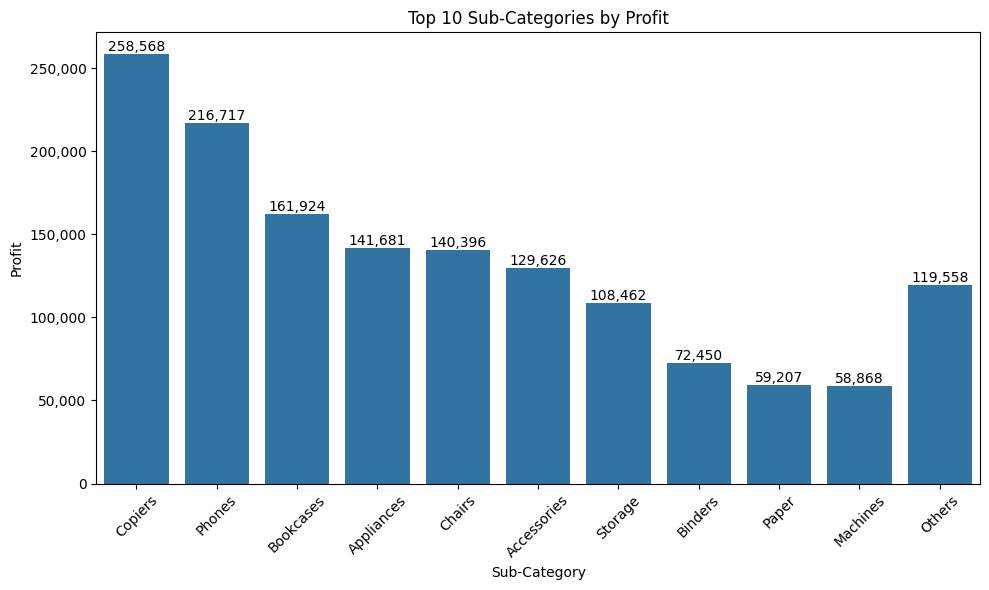

In [50]:
# profit by sub category

profit_data = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

top10 = profit_data.head(10)

others = profit_data.iloc[10:].sum()

top10['Others'] = others

plot_data = top10.reset_index()
plot_data.columns = ['Sub-Category', 'Profit']

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_data,
    x='Sub-Category',
    y='Profit'
)

ax.yaxis.set_major_formatter(
    StrMethodFormatter('{x:,.0f}')
)

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width()/2,
         bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Top 10 Sub-Categories by Profit')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

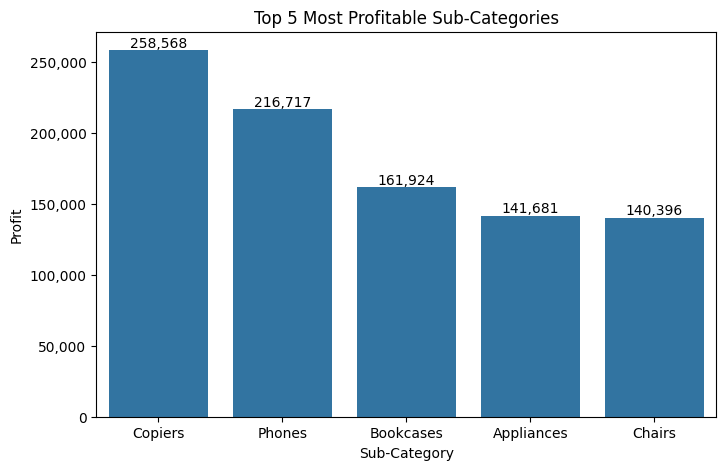

In [51]:
# profit by category

category_profit = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=category_profit,
    x='Sub-Category',
    y='Profit'
)

ax.yaxis.set_major_formatter(
    StrMethodFormatter('{x:,.0f}')
)

for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width()/2,
         bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Top 5 Most Profitable Sub-Categories')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')

plt.show()

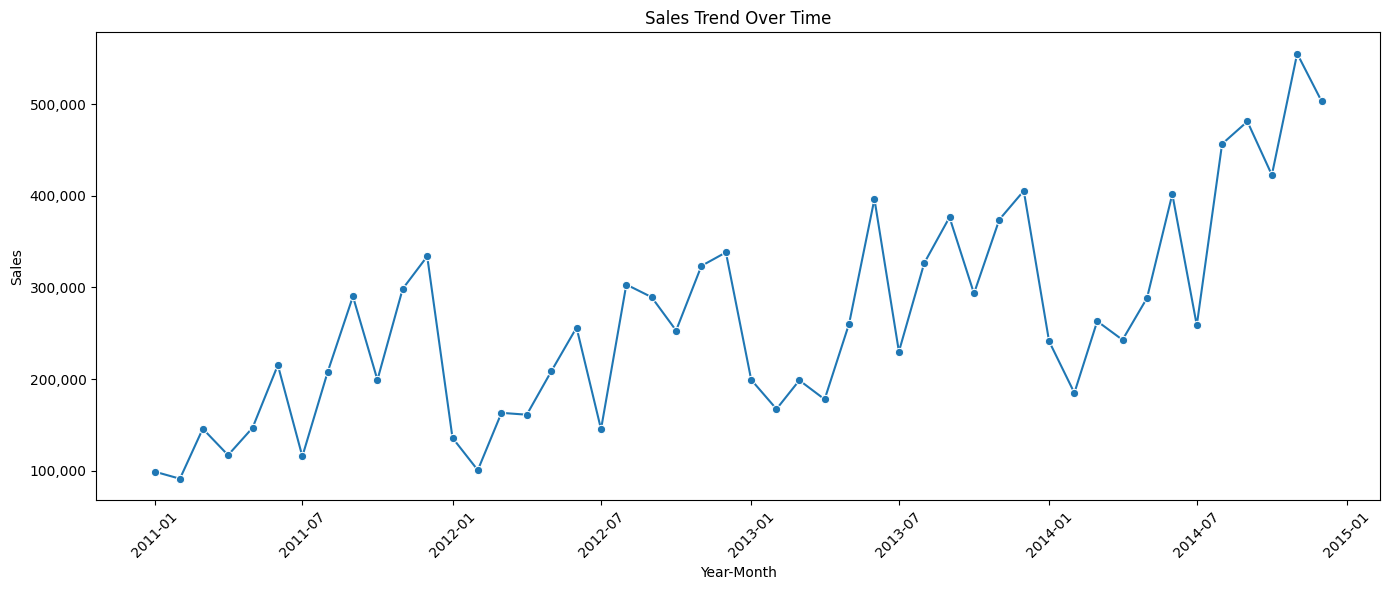

In [52]:
# Sales trend over time

df['Trend Date'] = pd.to_datetime(
    df['Order Year'].astype(str)
    + '-'
    + df['Order Month'].astype(str)
    + '-01'
)

sales_trend = (
    df.groupby('Trend Date')['Sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

ax = sns.lineplot(
    data=sales_trend,
    x='Trend Date',
    y='Sales',
    marker='o'
)

ax.yaxis.set_major_formatter(
    StrMethodFormatter('{x:,.0f}')
)

plt.title('Sales Trend Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

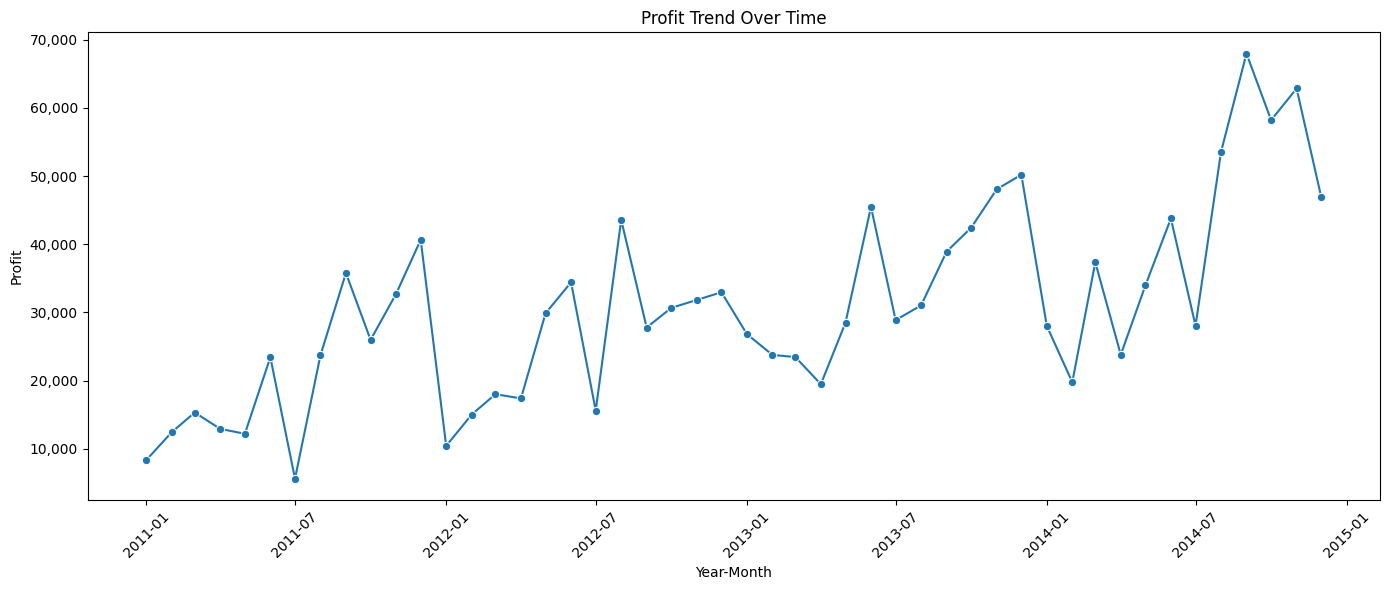

In [53]:
# profit trend over time

profit_trend = (
    df.groupby('Trend Date')['Profit']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

ax = sns.lineplot(
    data=profit_trend,
    x='Trend Date',
    y='Profit',
    marker='o'
)

ax.yaxis.set_major_formatter(
    StrMethodFormatter('{x:,.0f}')
)

plt.title('Profit Trend Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

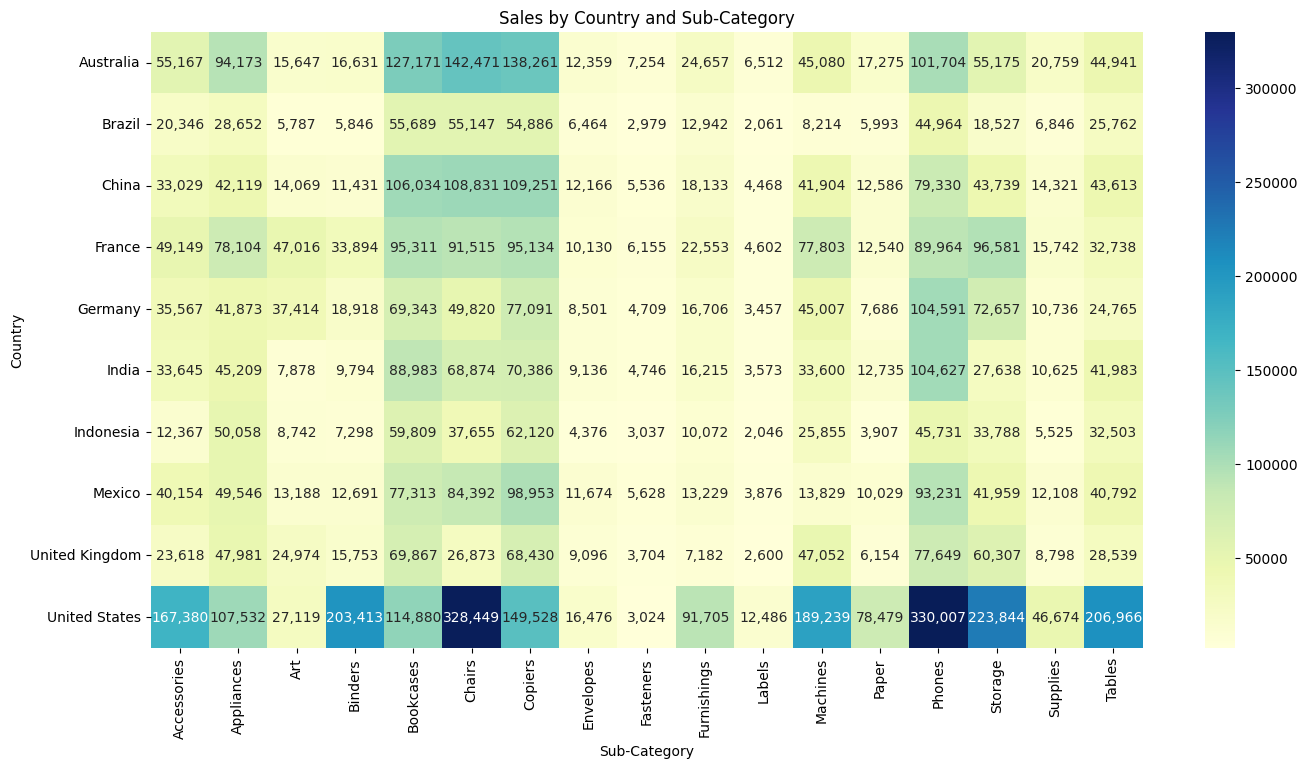

In [54]:
# top 10 countries by subcategory

top_countries = (
    df.groupby('Country')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

heatmap_data = (
    df[df['Country'].isin(top_countries)]
    .pivot_table(
        values='Sales',
        index='Country',
        columns='Sub-Category',
        aggfunc='sum'
    )
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt=',.0f'
)

plt.title('Sales by Country and Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Country')

plt.show()

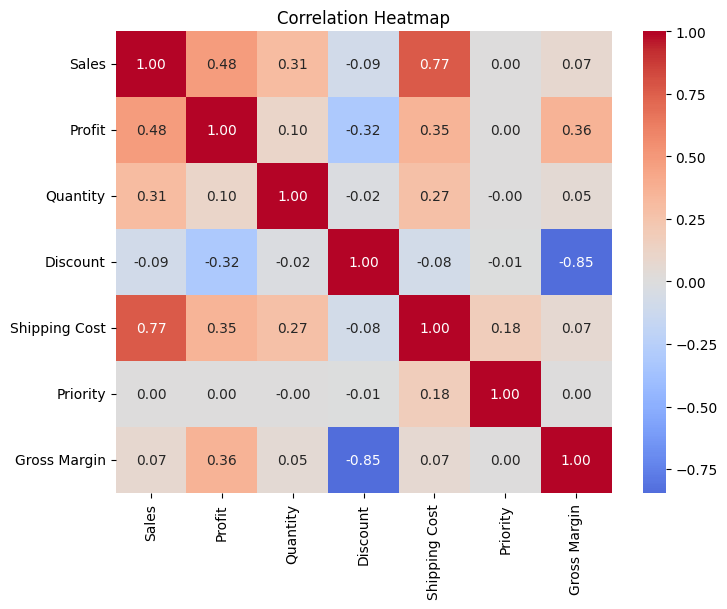

In [55]:
# affect of discount on profit
priority_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Critical': 4
}

df['Priority'] = (
    df['Order Priority']
    .map(priority_map)
)

corr_matrix = df[
    ['Sales',
     'Profit',
     'Quantity',
     'Discount',
     'Shipping Cost',
     'Priority',
     'Gross Margin']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
import openpyxl

#df.to_excel('Global_Superstore_Cleaned.xlsx', index=False)
#df.to_csv('Global_Superstore_Cleaned.csv', index=False)

In [ ]:
len(df)